In [1]:
!pip install imbalanced-learn scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 14.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 6.4 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [imbalanced-learn][imbalanced-learn]

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


We will start by creating a synthetic imbalanced dataset.

Original training set size: 700
Original minority class count: 35


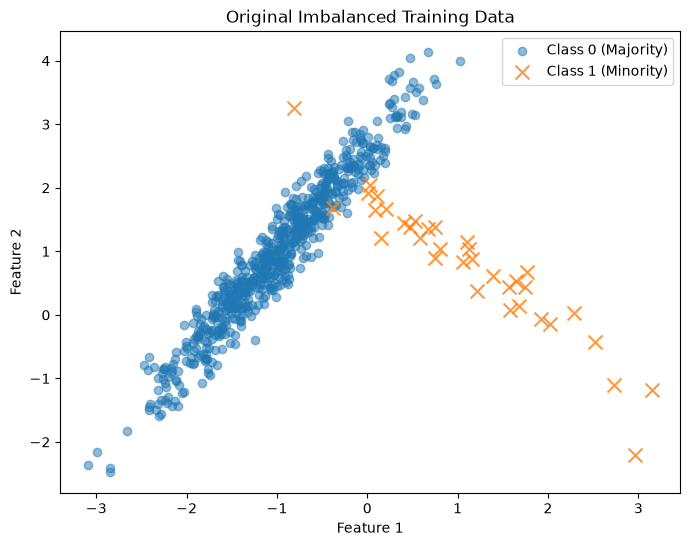

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN

# Create a synthetic imbalanced dataset
# The 'weights' parameter controls the class imbalance
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=2,
                           n_clusters_per_class=1, weights=[0.95, 0.05],
                           flip_y=0, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Function to plot the data
def plot_dataset(X, y, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Class 0 (Majority)', alpha=0.5)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Class 1 (Minority)', alpha=0.8, s=100, marker='x')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

print(f"Original training set size: {X_train.shape[0]}")
print(f"Original minority class count: {np.sum(y_train == 1)}")
plot_dataset(X_train, y_train, "Original Imbalanced Training Data")

SMOTE-resampled training set size: 1330
SMOTE minority class count: 665


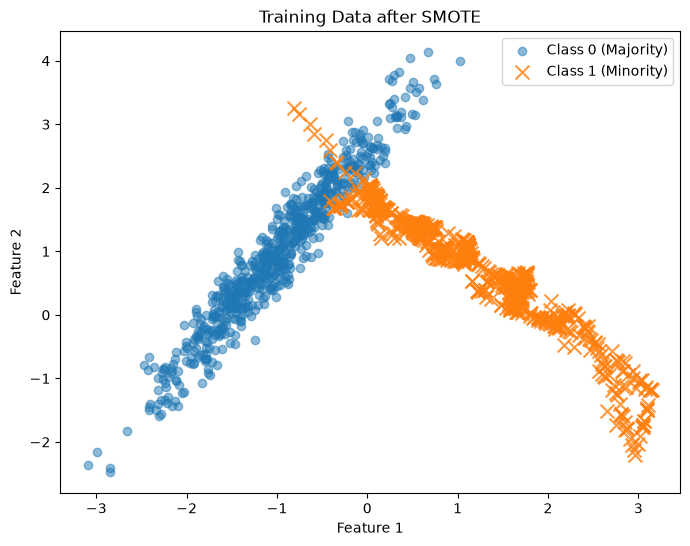

In [4]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print(f"SMOTE-resampled training set size: {X_smote.shape[0]}")
print(f"SMOTE minority class count: {np.sum(y_smote == 1)}")

# Plot the new dataset
plot_dataset(X_smote, y_smote, "Training Data after SMOTE")

As you can see from the plot, SMOTE has created new synthetic points (the 'x' marks) around the original minority points.

ADASYN-resampled training set size: 1331
ADASYN minority class count: 666


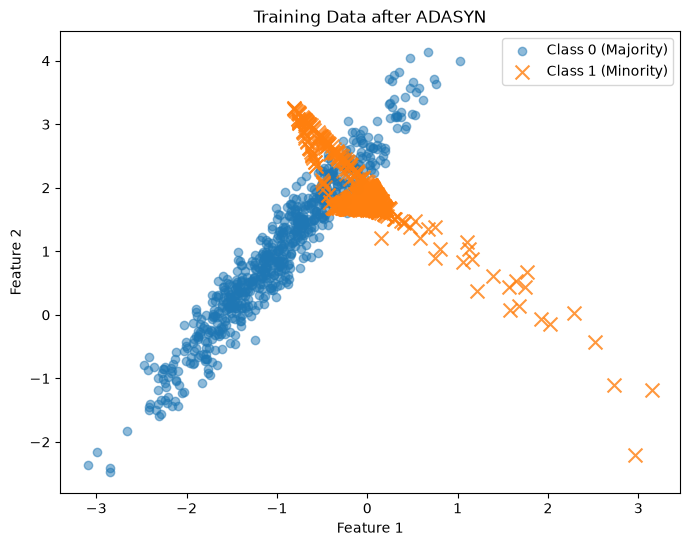

In [5]:
# Initialize ADASYN
adasyn = ADASYN(random_state=42)

# Apply ADASYN to the training data
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

print(f"ADASYN-resampled training set size: {X_adasyn.shape[0]}")
print(f"ADASYN minority class count: {np.sum(y_adasyn == 1)}")

# Plot the new dataset
plot_dataset(X_adasyn, y_adasyn, "Training Data after ADASYN")

Notice how the ADASYN plot shows a slightly different distribution of the new synthetic samples. They are more concentrated in the area where the minority class overlaps with the majority class, which is where the classification is most difficult. This is the key difference and the advantage of adaptive techniques.